<a href="https://colab.research.google.com/github/ryanaxiom/Applied-ML/blob/main/code/Day16_Carnegie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Student Instructions**: Before you begin, click **File > Save a copy in Drive** so you do not lose your work!

In [1]:
url = ("https://raw.githubusercontent.com/ryanaxiom/"
       "Applied-ML/main/data/carnegie_data.csv")

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold, cross_val_predict
carnegie_raw = pd.read_csv(url, encoding="cp1252")
carnegie = carnegie_raw.copy()
carnegie["research"] = carnegie["serd"] + carnegie["nonserd"]
d = carnegie[carnegie["research"].notna()].copy()
d["med_yn"] = (d["medical"] == 1).astype(int)
y = d["research"]
def rmse(a, b): return np.sqrt(np.mean((a - b)**2))
kf = KFold(n_splits=5, shuffle=True, random_state=309)
cands = ["fallenr20", "fallfte20", "ugtenr20", "grtenr20", "totdeg",
         "docrsdeg", "stem_rsd", "socsc_rsd", "hum_rsd", "oth_rsd",
         "facnum", "pdnfrstaff", "rooms", "numcip2", "pctadmitf20",
         "med_yn"]
d.shape, len(cands)

((302, 103), 16)

In [2]:
rng = np.random.default_rng(309)
neg, zero = {"ols": 0, "ridge": 0}, {"docrsdeg": 0, "stem_rsd": 0}
for b in range(200):
    rows = rng.choice(len(d), size=len(d), replace=True)
    for name, est in [("ols", LinearRegression()),
                      ("ridge", Ridge(alpha=100))]:
        m = make_pipeline(StandardScaler(), est)
        m.fit(d[cands].iloc[rows], y.iloc[rows])
        neg[name] += int(m[-1].coef_[cands.index("docrsdeg")] < 0)
    las = make_pipeline(StandardScaler(), Lasso(alpha=3162))
    las.fit(d[cands].iloc[rows], y.iloc[rows])
    for c in zero:
        zero[c] += int(las[-1].coef_[cands.index(c)] == 0)
print(neg, zero)

{'ols': 133, 'ridge': 0} {'docrsdeg': 186, 'stem_rsd': 2}


In [4]:
x = d[["facnum"]]                        # one column, standardized
for a in [1000, 10000, 100000, 300000]:
    r = make_pipeline(StandardScaler(), Ridge(alpha=a))
    r.fit(x, y)
    l = make_pipeline(StandardScaler(), Lasso(alpha=a))
    l.fit(x, y)
    print(a, round(r[-1].coef_[0]), round(l[-1].coef_[0]))

1000 68367 293750
10000 8640 284750
100000 887 194750
300000 296 0


In [5]:
alphas = np.logspace(3, 5, 21)        # 1,000 to 100,000
cv, kept = [], []
for a in alphas:
    pipe = make_pipeline(StandardScaler(), Lasso(alpha=a))
    oof = cross_val_predict(pipe, d[cands], y, cv=kf)
    cv.append(rmse(y, oof))
    pipe.fit(d[cands], y)
    kept.append(int((pipe[-1].coef_ != 0).sum()))
i = int(np.argmin(cv))
print(round(alphas[i]), round(cv[i]), kept[i])
print(round(cv[0]), kept[0], round(cv[-1]), kept[-1])

3162 232417 10
233604 12 245282 3


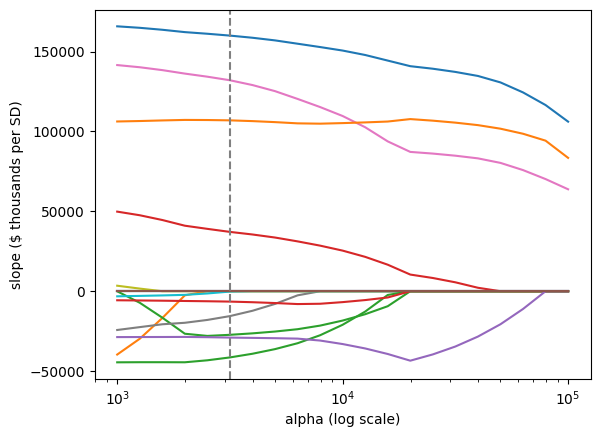

In [6]:
import matplotlib.pyplot as plt

paths = []
for a in alphas:
    m = make_pipeline(StandardScaler(), Lasso(alpha=a))
    m.fit(d[cands], y)
    paths.append(m[-1].coef_)
plt.semilogx(alphas, paths)
plt.axvline(alphas[i], linestyle="--", color="gray")
plt.xlabel("alpha (log scale)")
plt.ylabel("slope ($ thousands per SD)")
plt.show()

In [7]:
ridge_s = make_pipeline(StandardScaler(), Ridge(alpha=100))
ridge_s.fit(d[cands], y)
lasso_s = make_pipeline(StandardScaler(), Lasso(alpha=alphas[i]))
lasso_s.fit(d[cands], y)
coefs = pd.DataFrame({"ridge": ridge_s[-1].coef_,
                      "lasso": lasso_s[-1].coef_}, index=cands)
show = ["stem_rsd", "docrsdeg", "facnum", "pdnfrstaff", "med_yn"]
print(coefs.loc[show].round().astype(int))
print(list(coefs.index[coefs["lasso"] == 0]))
print(np.abs(coefs).sum().round().astype(int))

            ridge   lasso
stem_rsd    70309  132014
docrsdeg    43254       0
facnum      98933  159958
pdnfrstaff  84314  106922
med_yn      20568       0
['fallenr20', 'fallfte20', 'totdeg', 'docrsdeg', 'hum_rsd', 'med_yn']
ridge    471490
lasso    555987
dtype: int64


In [8]:
from sklearn.model_selection import cross_val_score
models = {"ols": LinearRegression(), "ridge": Ridge(alpha=100),
          "lasso": Lasso(alpha=alphas[i])}
for name, est in models.items():
    m = make_pipeline(StandardScaler(), est)
    folds = -cross_val_score(m, d[cands], y, cv=kf,
                             scoring="neg_mean_squared_error")
    print(name, np.sqrt(folds).round().astype(int))
    m.fit(d[cands], y)
    print("   in-sample", round(rmse(y, m.predict(d[cands]))))

ols [176836 177464 352193 267755 152954]
   in-sample 165237
ridge [193340 148692 208521 291629 149322]
   in-sample 176546
lasso [174505 165837 341339 272691 148646]
   in-sample 166095


In [9]:
pile = ["fallenr20", "totdeg", "facnum", "stem_rsd", "med_yn"]
rng = np.random.default_rng(309)
noise = pd.DataFrame(rng.normal(size=(len(d), 1000)),
                     index=d.index).add_prefix("noise")
for k in [20, 100, 1000]:
    both = pd.concat([d[pile], noise.iloc[:, :k]], axis=1)
    for est, grid in [(Ridge, np.logspace(-2, 5, 29)),
                      (Lasso, np.logspace(3, 5, 21))]:
        cvk = []
        for a in grid:
            pipe = make_pipeline(StandardScaler(), est(alpha=a))
            oof = cross_val_predict(pipe, both, y, cv=kf)
            cvk.append(rmse(y, oof))
        print(k, est.__name__, round(min(cvk)))

20 Ridge 214310
20 Lasso 206289
100 Ridge 250913
100 Lasso 208469
1000 Ridge 315478
1000 Lasso 214196


In [10]:
from sklearn.model_selection import GridSearchCV
pipe = make_pipeline(StandardScaler(), Lasso())
grid = {"lasso__alpha": np.logspace(3, 5, 21)}
search = GridSearchCV(pipe, grid, cv=kf,
                      scoring="neg_mean_squared_error")
search.fit(d[cands], y)
print(round(search.best_params_["lasso__alpha"]),
      round(np.sqrt(-search.best_score_)))
honest = cross_val_score(search, d[cands], y, cv=kf,
                         scoring="neg_mean_squared_error")
print(round(np.sqrt(-honest.mean())))

3162 232775
235165


In [11]:
truth = LinearRegression()
truth.fit(d[pile], y)
f = truth.predict(d[pile])              # the truth: five of sixteen
a_r, a_l = np.logspace(-2, 4, 13), np.logspace(3.5, 5, 13)
rng = np.random.default_rng(309)
pr, pl = np.zeros((13, 100, len(f))), np.zeros((13, 100, len(f)))
for w in range(100):                      # 100 worlds
    y_w = f + (y - f) * rng.choice([-1, 1], len(f))
    for j in range(13):
        r = make_pipeline(StandardScaler(), Ridge(alpha=a_r[j]))
        pr[j, w] = r.fit(d[cands], y_w).predict(d[cands])
        l = make_pipeline(StandardScaler(), Lasso(alpha=a_l[j]))
        pl[j, w] = l.fit(d[cands], y_w).predict(d[cands])
for name, p, a in [("ridge", pr, a_r), ("lasso", pl, a_l)]:
    bias2 = ((p.mean(axis=1) - f)**2).mean(axis=1)
    var = p.var(axis=1).mean(axis=1)
    j = int(np.argmin(bias2 + var))
    print(name, a[j].round(1), round(np.sqrt(bias2[j] + var[j])))

ridge 10.0 61194
lasso 10000.0 51643
